
# BCG unsuitable-segment estimation using wavelets

This notebook implements the core segmentation idea from the paper:

**“An Improved Estimation of Unsuitable Segments of Ballistocardiography Records Using Wavelet Transforms.”**


## OBS

This notebook is a practical re-implementation based on the paper description. A few details are not fully specified in the paper, so the implementation makes reasonable engineering choices:

- the paper states a 1-second moving window
- the paper uses the **Gaus2** mother wavelet at **scale 16**
- the paper defines:
  - `Ws = (W1 + W2)/2`
  - `Thd_max = mean(W1 + W2)`
  - `Thd_min = mean(W1 + W2) * 0.1`
- the paper expands each threshold crossing by **±150 ms**


In [14]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
import pywt
from pathlib import Path

plt.rcParams["figure.figsize"] = (14, 5)



## 1. Helper functions

This is a list of helper functions. Some of them are probably irrelevant now


In [15]:

def bandpass_filter(x, fs, lowcut, highcut, order=4):
    x = np.asarray(x, dtype=float)
    x = signal.detrend(x)
    sos = signal.butter(order, [lowcut, highcut], btype="bandpass", fs=fs, output="sos")
    return signal.sosfiltfilt(sos, x)


def moving_std(x, window_samples):
    s = pd.Series(np.asarray(x, dtype=float))
    return s.rolling(window=window_samples, center=True, min_periods=1).std(ddof=0).to_numpy()


def moving_var(x, window_samples):
    s = pd.Series(np.asarray(x, dtype=float))
    return s.rolling(window=window_samples, center=True, min_periods=1).var(ddof=0).to_numpy()


def expand_mask(mask, radius_samples):
    mask = np.asarray(mask, dtype=bool)
    kernel = np.ones(2 * radius_samples + 1, dtype=int)
    expanded = np.convolve(mask.astype(int), kernel, mode="same") > 0
    return expanded


def cwt_gaus2_scale16(x):
    coeffs, freqs = pywt.cwt(x, scales=[16], wavelet="gaus2")
    return coeffs[0]


def segmentation_proposed(bcg, fs):
    window_samples = int(fs * 2.0) ##These are mostly guesses since the paper doesn't say what they sbould be, expect fluffyness!
    margin_samples = int(fs * 0.3) ## -||-

    cwt_bcg = cwt_gaus2_scale16(bcg)

    W1 = moving_std(bcg, window_samples)
    W2 = moving_std(cwt_bcg, window_samples)

    Ws = (W1 + W2) / 2.0

    thd_max = np.mean(W1 + W2)
    thd_min = np.mean(W1 + W2) * 0.1

    high_artifact = Ws > thd_max
    low_signal = Ws < thd_min

    high_artifact_expanded = expand_mask(high_artifact, margin_samples)
    low_signal_expanded = expand_mask(low_signal, margin_samples)

    seg = np.ones_like(Ws, dtype=int)
    seg[low_signal_expanded] = 0
    seg[high_artifact_expanded] = 2

    return {
        "cwt_bcg": cwt_bcg,
        "W1": W1,
        "W2": W2,
        "Ws": Ws,
        "thd_max": thd_max,
        "thd_min": thd_min,
        "seg": seg,
        "usable_mask": seg == 1,
        "artifact_mask": seg == 2,
        "low_signal_mask": seg == 0,
    }


def segmentation_variance_baseline(bcg, fs):
    window_samples = int(fs * 0.1)
    margin_samples = int(fs * 0.0150)

    Wvar = moving_var(bcg, window_samples)

    thd_max = np.mean(Wvar)
    thd_min = np.mean(Wvar) * 0.1

    high_artifact = Wvar > thd_max
    low_signal = Wvar < thd_min

    high_artifact_expanded = expand_mask(high_artifact, margin_samples)
    low_signal_expanded = expand_mask(low_signal, margin_samples)

    seg = np.ones_like(Wvar, dtype=int)
    seg[low_signal_expanded] = 0
    seg[high_artifact_expanded] = 2

    return {
        "Wvar": Wvar,
        "thd_max": thd_max,
        "thd_min": thd_min,
        "seg": seg,
        "usable_mask": seg == 1,
        "artifact_mask": seg == 2,
        "low_signal_mask": seg == 0,
    }


def detect_ecg_rpeaks(ecg, fs):
    distance = int(0.6 * fs) #Increase this to increase length of the local area for local maxima & minima
    prominence = np.std(ecg) * 0.7 #Increase this to increase the "prominence" essentially keep only those that are at least x above their local group
    peaks, props = signal.find_peaks(ecg, distance=distance, prominence=prominence)
    return peaks


def coverage_factor_from_ecg(seg_usable_mask, rpeaks):
    if len(rpeaks) == 0:
        return np.nan, 0, 0
    usable_beats = int(np.sum(seg_usable_mask[rpeaks]))
    total_beats = len(rpeaks)
    cf = 100.0 * usable_beats / total_beats
    return cf, usable_beats, total_beats



## 2. Load the data

This loads the data from the csv file 



In [16]:

DATA_PATH = Path("Sitting_april13_Christian.csv")
TIME_COLUMN = "unix_time_s"
BCG_COLUMN = "voltage_a0"
AUX_COLUMN = "voltage_a3"
ECG_COLUMN = None

df = pd.read_csv(DATA_PATH)
bcg_raw = df[BCG_COLUMN].to_numpy(dtype=float)
aux_raw = df[AUX_COLUMN].to_numpy(dtype=float) if AUX_COLUMN in df.columns else None
ecg_raw = None

time_unix = df[TIME_COLUMN].to_numpy(dtype=float)
time = time_unix - time_unix[0]

dt = np.diff(time)
dt = dt[np.isfinite(dt) & (dt > 0)]
if len(dt) == 0:
    FS = 200.0
    time = np.arange(len(bcg_raw)) / FS
else:
    FS = float(np.round(1.0 / np.median(dt)))

print(f"Loaded {DATA_PATH.name} with {len(bcg_raw)} samples.")
print(f"Using FS = {FS:.2f} Hz")
print(f"BCG column: {BCG_COLUMN}")
print(f"Aux column: {AUX_COLUMN if aux_raw is not None else 'None'}")


Loaded Sitting_april13_Christian.csv with 60000 samples.
Using FS = 200.00 Hz
BCG column: voltage_a0
Aux column: voltage_a3


In [ ]:
DATA_PATH = Path("Sitting_april13_Christian_ECG.csv")
TIME_COLUMN = "unix_time_s"
BCG_COLUMN = "voltage_a0"
AUX_COLUMN = "voltage_a3"
ECG_COLUMN = None

df = pd.read_csv(DATA_PATH)
ecg_raw = df[BCG_COLUMN].to_numpy(dtype=float)

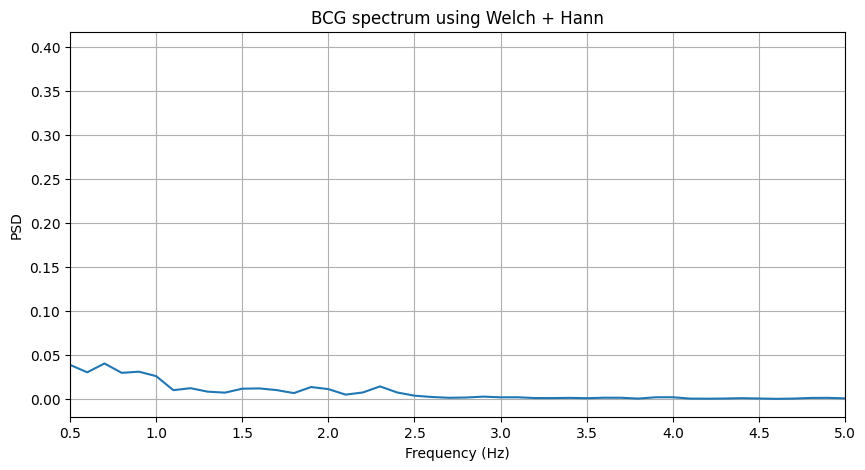

Estimated heart rate: 42.0 bpm


In [22]:
from scipy.signal import welch



signal = bcg_raw.copy()
signal = signal - np.mean(signal)

f, Pxx = welch(signal, fs=FS, window='hann', nperseg=int(FS*10), noverlap=int(FS*5))

plt.figure(figsize=(10, 5))
plt.plot(f, Pxx)
plt.xlim(0.5, 5)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.title("BCG spectrum using Welch + Hann")
plt.grid(True)
plt.show()

band = (f >= 0.7) & (f <= 3.0)
peak_freq = f[band][np.argmax(Pxx[band])]
print(f"Estimated heart rate: {peak_freq * 60:.1f} bpm")


## 4. Preprocess signals

According to the paper:
- BCG bandwidth: `0.3–24 Hz`
- ECG bandwidth: `0.5–40 Hz`


Preprocessing complete.
Raw range: 0.0000 to 3.9016
Filtered range: -2.1882 to 2.0955


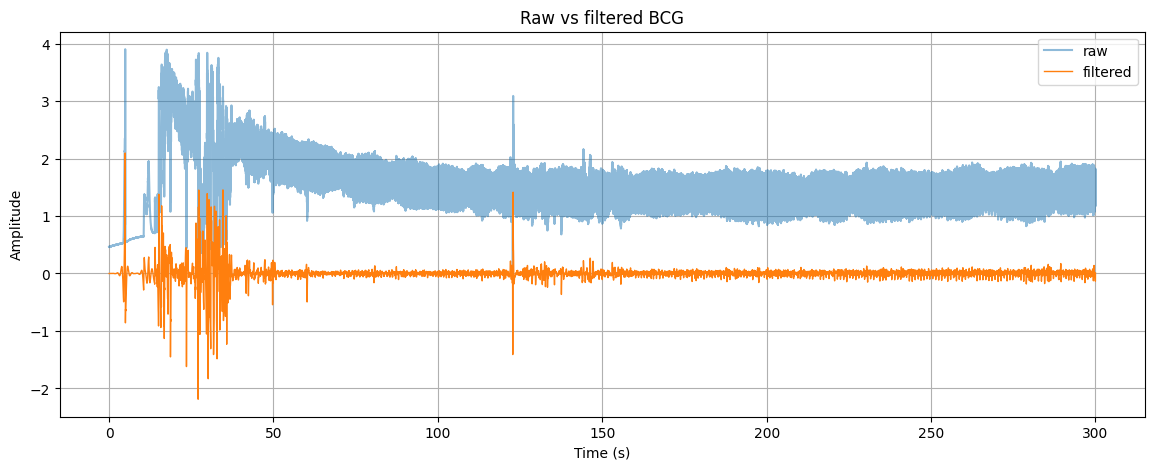

In [21]:
from scipy import signal

bcg = bandpass_filter(bcg_raw, FS, 0.8, 12.0, order=4)

if ecg_raw is not None:
    ecg = bandpass_filter(ecg_raw, FS, 0.5, 40.0, order=4)
else:
    ecg = None

print("Preprocessing complete.")
print(f"Raw range: {bcg_raw.min():.4f} to {bcg_raw.max():.4f}")
print(f"Filtered range: {bcg.min():.4f} to {bcg.max():.4f}")

plt.figure(figsize=(14, 5))
plt.plot(time, bcg_raw, label="raw", alpha=0.5)
plt.plot(time, bcg, label="filtered", linewidth=1)
plt.title("Raw vs filtered BCG")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()


### Thresholds according to the paper

In [ ]:

res_prop = segmentation_proposed(bcg, FS)
res_var = segmentation_variance_baseline(bcg, FS)
thd_max = res_prop["thd_max"]
thd_min = res_prop["thd_min"]


print("Proposed method thresholds:")
print("  thd_max =", res_prop["thd_max"])
print("  thd_min =", res_prop["thd_min"])

print("\nVariance baseline thresholds:")
print("  thd_max =", res_var["thd_max"])
print("  thd_min =", res_var["thd_min"])


Proposed method thresholds:
  thd_max = 0.3304911444297764
  thd_min = 0.03304911444297764

Variance baseline thresholds:
  thd_max = 0.004763314776670025
  thd_min = 0.00047633147766700255


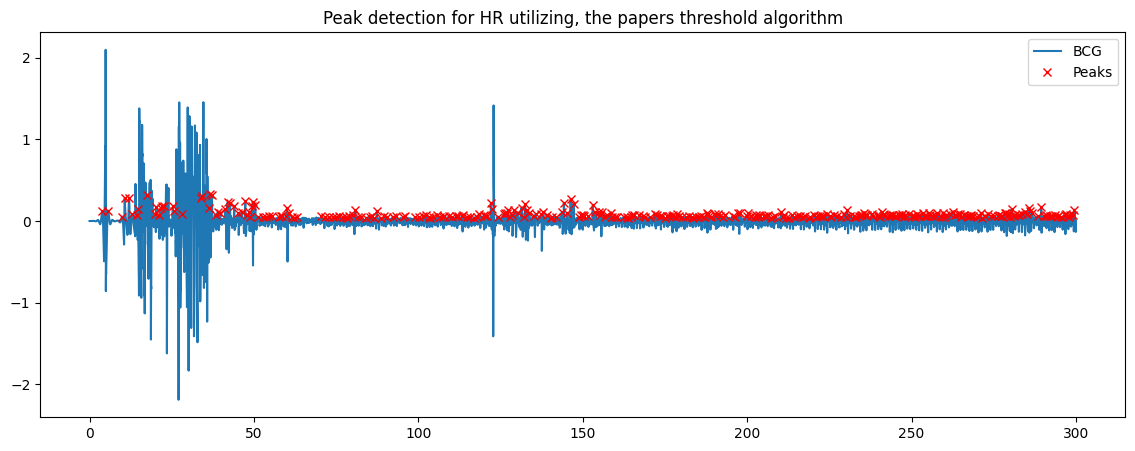

Heart Rate: 69.8 bpm
Number of peaks: 345


In [ ]:
from scipy import signal

# --- PEAK DETECTION ---
peaks, _ = signal.find_peaks(
    bcg,
    distance=0.3* FS,
    prominence=np.std(bcg) * 0.6
)
peak_values = bcg[peaks]
#print(peak_values[:10])
mask = (peak_values > thd_min) & (peak_values < thd_max)
filtered_peaks = peaks[mask]

### THIS IS WITHOUT THRESHOLD
# Plot to verify
""" plt.figure(figsize=(14,5))
plt.plot(time, bcg, label="BCG")
plt.plot(time[peaks], bcg[peaks], "rx", label="Peaks")
plt.legend()
plt.title("Peak detection for HR")
plt.show()



# --- HEART RATE ---
if len(peaks) > 2:
    rr = np.diff(time[peaks])
    hr = 60 / np.mean(rr)
    print(f"Heart rate: {hr:.1f} bpm")
else:
    print("Not enough peaks to estimate HR")

print("Number of peaks:", len(peaks)) """


### THIS IS WITH THRESHOLD
# Real plot (with threshold)
plt.figure(figsize=(14,5))
plt.plot(time, bcg, label="BCG")
plt.plot(time[filtered_peaks], bcg[filtered_peaks], "rx", label="Peaks")
plt.legend()
plt.title("Peak detection for HR utilizing, the papers threshold algorithm")
plt.show()

## TRUE HEART RATE 
if len(mask) > 2: 
    rr = np.diff(time[filtered_peaks])
    hr = 60/np.mean(rr) 
    print(f"Heart Rate: {hr:.1f} bpm")
    print("Number of peaks:", len(filtered_peaks))
else: 
    print("Not enough peaks to estimate HR")





## 6. Plot full-record overview


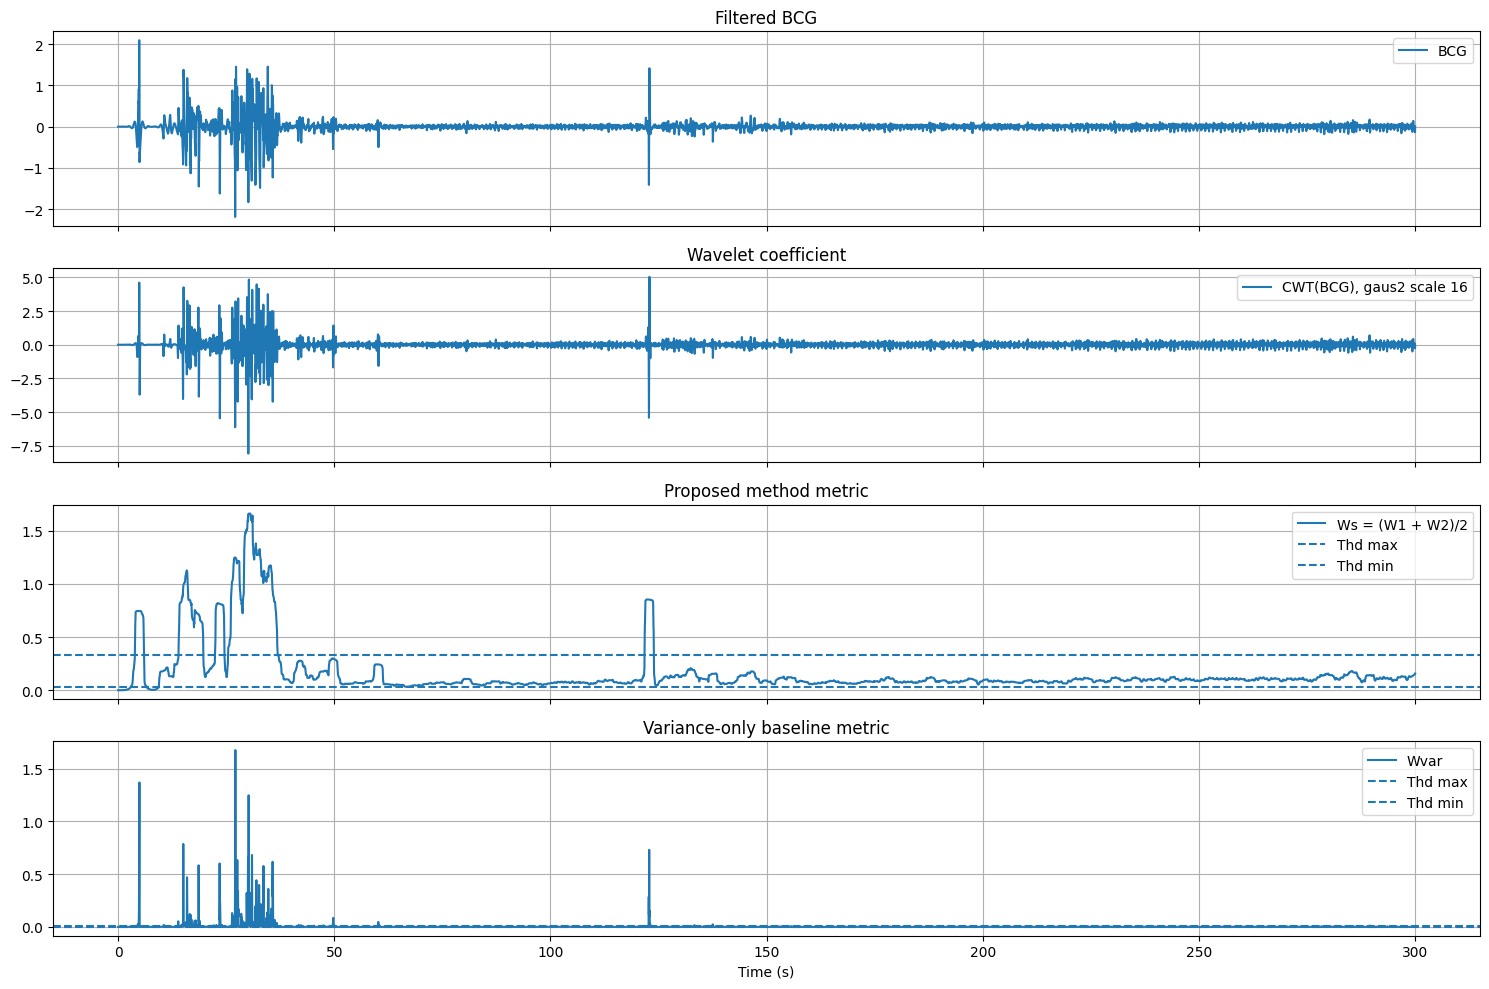

In [ ]:

fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)

axes[0].plot(time, bcg, label="BCG")
axes[0].set_title("Filtered BCG")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(time, res_prop["cwt_bcg"], label="CWT(BCG), gaus2 scale 16")
axes[1].set_title("Wavelet coefficient")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(time, res_prop["Ws"], label="Ws = (W1 + W2)/2")
axes[2].axhline(res_prop["thd_max"], linestyle="--", label="Thd max")
axes[2].axhline(res_prop["thd_min"], linestyle="--", label="Thd min")
axes[2].set_title("Proposed method metric")
axes[2].legend()
axes[2].grid(True)

axes[3].plot(time, res_var["Wvar"], label="Wvar")
axes[3].axhline(res_var["thd_max"], linestyle="--", label="Thd max")
axes[3].axhline(res_var["thd_min"], linestyle="--", label="Thd min")
axes[3].set_title("Variance-only baseline metric")
axes[3].legend()
axes[3].grid(True)

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()



## 7. Plot segmentation labels

Label meaning:
- `0` = weak / absent signal
- `1` = usable
- `2` = artifact / large variation


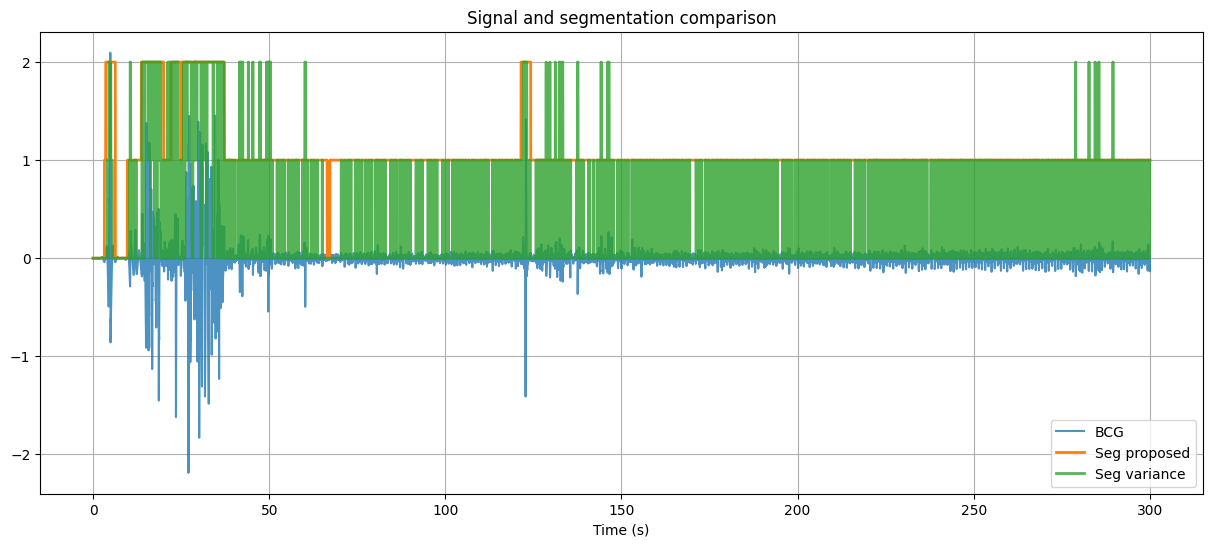

In [ ]:

plt.figure(figsize=(15, 6))
plt.plot(time, bcg, label="BCG", alpha=0.8)
plt.plot(time, res_prop["seg"], label="Seg proposed", linewidth=2)
plt.plot(time, res_var["seg"], label="Seg variance", linewidth=2, alpha=0.8)
if ecg is not None:
    plt.plot(time, ecg, label="ECG", alpha=0.7)
plt.title("Signal and segmentation comparison")
plt.xlabel("Time (s)")
plt.legend()
plt.grid(True)
plt.show()



## 8. Zoom into a time interval

Change `t0` and `t1` to inspect examples like the figures in the paper.


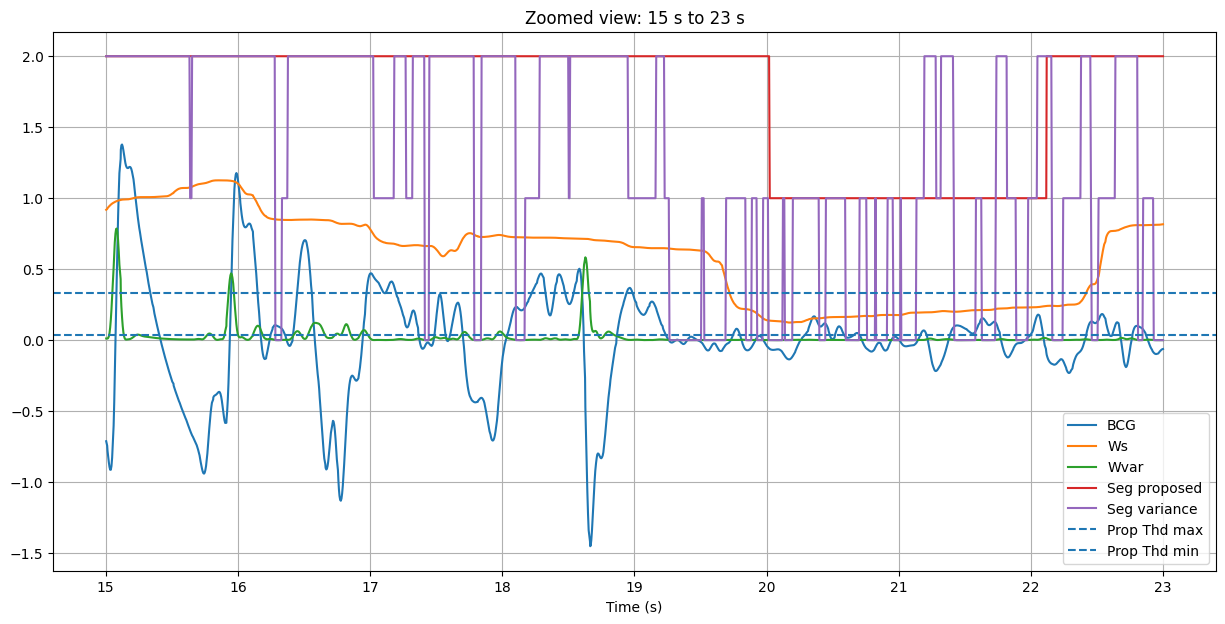

In [ ]:

t0, t1 = 15, 23
idx = (time >= t0) & (time <= t1)

plt.figure(figsize=(15, 7))
plt.plot(time[idx], bcg[idx], label="BCG")
plt.plot(time[idx], res_prop["Ws"][idx], label="Ws")
plt.plot(time[idx], res_var["Wvar"][idx], label="Wvar")
plt.plot(time[idx], res_prop["seg"][idx], label="Seg proposed")
plt.plot(time[idx], res_var["seg"][idx], label="Seg variance")
plt.axhline(res_prop["thd_max"], linestyle="--", label="Prop Thd max")
plt.axhline(res_prop["thd_min"], linestyle="--", label="Prop Thd min")
plt.title(f"Zoomed view: {t0} s to {t1} s")
plt.xlabel("Time (s)")
plt.legend()
plt.grid(True)
plt.show()



## 9. Coverage factor (CF) using ECG beat counts

The paper defines coverage factor as:

`CF = suitable heartbeats / total heartbeats × 100`

This cell uses ECG R-peaks as the reference heartbeat count.


In [ ]:

if ecg is not None:
    rpeaks = detect_ecg_rpeaks(ecg, FS)

    cf_prop, usable_prop, total_beats = coverage_factor_from_ecg(res_prop["usable_mask"], rpeaks)
    cf_var, usable_var, _ = coverage_factor_from_ecg(res_var["usable_mask"], rpeaks)

    print(f"Total beats: {total_beats}")
    print(f"Proposed method: CF = {cf_prop:.2f}% ({usable_prop}/{total_beats})")
    print(f"Variance baseline: CF = {cf_var:.2f}% ({usable_var}/{total_beats})")
    print(f"Difference in beats kept: {usable_prop - usable_var}")
else:
    print("No ECG available, so CF cannot be computed in this cell.")


No ECG available, so CF cannot be computed in this cell.



## 10. Optional: save segmentation results


In [ ]:

out = pd.DataFrame({
    "time_s": time,
    "bcg_filtered": bcg,
    "cwt_bcg": res_prop["cwt_bcg"],
    "W1_std_bcg": res_prop["W1"],
    "W2_std_cwt": res_prop["W2"],
    "Ws": res_prop["Ws"],
    "seg_proposed": res_prop["seg"],
    "Wvar": res_var["Wvar"],
    "seg_variance": res_var["seg"],
})

if ecg is not None:
    out["ecg_filtered"] = ecg

OUT_PATH = Path("bcg_segmentation_results.csv")
out.to_csv(OUT_PATH, index=False)
print(f"Saved results to {OUT_PATH.resolve()}")


Saved results to C:\Users\Christian Damsgaard\Documents\DTU\Bachelor\Code\Darkstar\bcg_segmentation_results.csv
